In [1]:
import torch
import numpy as np
from torchvision.datasets import EMNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import random
import torch.nn.functional as F

batch_size=128

transform = transforms.Compose([
    transforms.Lambda(lambda img : img.rotate(-90, expand=True)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_data = EMNIST(root = './data',transform=transform, split='digits', download = True, train=True)
test_data = EMNIST(root = './data', transform = transform, split='digits', download= True, train=False)

100%|██████████| 562M/562M [00:01<00:00, 336MB/s]


In [2]:
HEIGHT = 28
WIDTH = 28
PAD = True
NUM_CLASSES = 10
MIN_LEN = 2
MAX_LEN =6

idx_to_char = train_data.classes

class EMNISTSyntheticDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, min_len = 2, max_len = 6, pad = True):
        self.base_dataset = base_dataset
        self.min_len = min_len
        self.max_len = max_len
        self.pad = pad
        self.max_width = WIDTH*max_len


    def __len__(self):
        return len(self.base_dataset) // self.min_len


    def __getitem__(self,idx):
        seq_len = random.randint(self.min_len, self.max_len)
        images = []
        labels = []

        for _ in range(seq_len):
            rand_idx = random.randint(0, len(self.base_dataset) - 1)
            img, label = self.base_dataset[rand_idx] 
            img = torch.flip(img , dims=[2])
            images.append(img)
            labels.append(label)

        stitched = torch.cat(images, dim=2)  

        if self.pad:
            stitched = self.pad_to_width(stitched, self.max_width)

        return stitched, torch.tensor(labels, dtype=torch.long), seq_len

    def pad_to_width(self, img, target_width):
        _, h, w = img.shape
        if w >= target_width:
            return img[:, :, :target_width]
        else:
            padding = target_width - w
            return F.pad(img, (0, padding), mode='constant', value=0)

train_dataset = EMNISTSyntheticDataset(
    train_data,
    min_len=MIN_LEN,
    max_len=MAX_LEN,
    pad=PAD
)

test_dataset = EMNISTSyntheticDataset(
    train_data,
    min_len=MIN_LEN,
    max_len=MAX_LEN,
    pad=PAD
)

In [3]:
def collate_fn(batch):
    imgs, labels, seq_len = zip(*batch)
    imgs = torch.stack(imgs)
    max_len = max(seq_len)

    padded_labels = []

    for label, length in zip(labels,seq_len):
        if length<max_len:
            pad_size=max_len-length
            padded=torch.cat([label[:length], torch.full((pad_size,),0,dtype=torch.long)])
        else:
            padded = label[:length]
        padded_labels.append(padded)

    padded_labels=torch.stack(padded_labels)
    seq_len = torch.tensor(seq_len)

    return imgs,padded_labels, seq_len

In [4]:
train_loader = DataLoader(train_dataset, shuffle =True, collate_fn=collate_fn, batch_size=batch_size, num_workers=4)
test_loader = DataLoader(test_dataset, shuffle =False, collate_fn=collate_fn, batch_size=batch_size, num_workers=4)

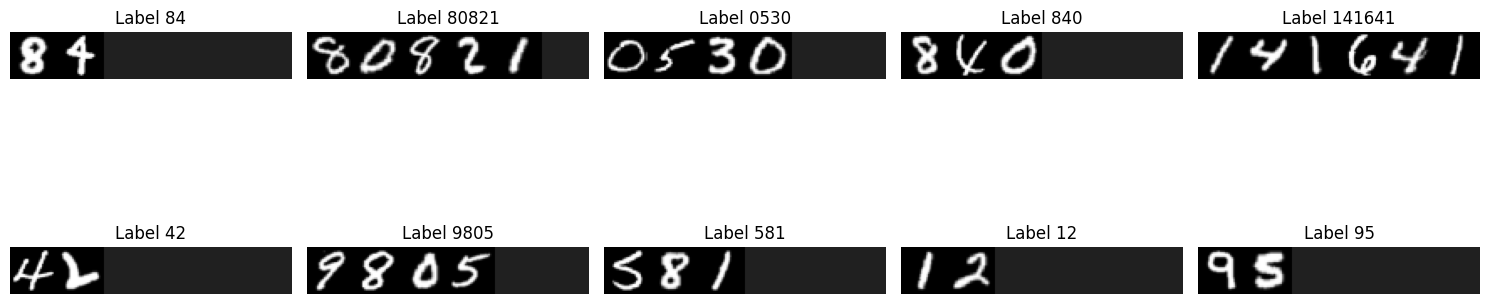

In [5]:
import matplotlib.pyplot as plt

number=10
fig, axes = plt.subplots(2,5,figsize=(15,6))
axes=axes.flatten()

count=0
for imgs,labels,seq_len in train_loader:
    batch_size=imgs.size(0)

    for i in range(batch_size):
        if count>=number:
            break

        img = imgs[i].squeeze(0).clone().detach().cpu()
        label = labels[i][:seq_len[i]].tolist()

        axes[count].imshow(img,cmap='gray')
        axes[count].set_title(f"Label {''.join(str(l) for l in label)}")
        axes[count].axis("off")

        count+=1
    if count>=number:
        break

plt.tight_layout()
plt.show()

In [6]:
import torch.nn as nn

class CRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(1,32,kernel_size=3)
        self.max1=nn.MaxPool2d(kernel_size=2,stride=2)
        self.conv2=nn.Conv2d(32,32,kernel_size=3)
        self.max2=nn.MaxPool2d(kernel_size=2,stride=2)
        self.relu=nn.ReLU()
        self.gru=nn.GRU(160,128,2,batch_first=True,bidirectional=True)
        self.fc=nn.Linear(256,11)

    def forward(self,x):
        out=self.conv1(x)
        out = self.relu(out)
        out=self.max1(out)
        
        out=self.conv2(out)
        out = self.relu(out)
        out=self.max2(out)

        batch,channel, height, width = out.size()
        out=out.permute(0,3,1,2)
        out=out.reshape(batch,width ,channel*height)
        
        out, _ = self.gru(out)
        out=self.fc(out)
        out=out.permute(1,0,2)

        return out

model=CRNN()
criterion = nn.CTCLoss(blank=10, reduction='mean', zero_infinity=True)
optimizer=torch.optim.RAdam(model.parameters(), lr = 0.001)

In [7]:
device=torch.device('cuda' if torch.cuda.is_available() else "cpu")
model=model.to(device)

In [8]:
num_epochs=10
training_losses=[]

for epoch in range(num_epochs):
    total_loss=0
    model.train()
    for images, labels, seq_len in train_loader:
        images =images.to(device)
        labels= labels.to(device)

        pred = model(images)
        log_probs = F.log_softmax(pred,dim=2)

        targets = []
        input_length=torch.full(size=(images.size(0),),fill_value=log_probs.size(0),device=device, dtype=torch.long)
        target_length=seq_len.to(device)

        for i in range(labels.size(0)):
            targets.append(labels[i][:seq_len[i]])

        targets = torch.cat(targets).to(device)
        
        loss=criterion(log_probs, targets, input_length, target_length)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()

    avg_loss = total_loss / len(train_loader)
    training_losses.append(avg_loss)

    print(f"Epochs {epoch+1}/{num_epochs} | Average Loss {avg_loss:.3f}")

Epochs 1/10 | Average Loss 1.980
Epochs 2/10 | Average Loss 0.050
Epochs 3/10 | Average Loss 0.029
Epochs 4/10 | Average Loss 0.021
Epochs 5/10 | Average Loss 0.016
Epochs 6/10 | Average Loss 0.014
Epochs 7/10 | Average Loss 0.012
Epochs 8/10 | Average Loss 0.009
Epochs 9/10 | Average Loss 0.009
Epochs 10/10 | Average Loss 0.007


In [9]:
label_to_char = [str(i) for i in range(10)]

In [10]:
def ctc_decode(log_probs, label_to_char):
    preds=log_probs.argmax(dim=2)
    preds=preds.permute(1,0)
    
    decoded=[]
    
    for seq in preds:
        prev=-1
        chars=[]
        for c in seq:
            c=c.item()
            if c!=prev and c!=10:
                if 0<=c<=9:
                    chars.append(label_to_char[c])
                else:
                    chars.append("?")
            prev=c
        decoded.append(''.join(chars) if chars else "?")
        
    return decoded

In [11]:
model.eval()
test_correct=0
test_total=0

with torch.no_grad():
    for x,y, seq_len in test_loader:
        x = x.to(device)
        y = y.to(device)
        seq_len = seq_len.to(device)
        
        pred = model(x)
        log_probs = F.log_softmax(pred, dim=2)
        preds = ctc_decode(log_probs ,label_to_char)

        for pred, true, length in zip(preds, y, seq_len):
            test_total+=1

            true_labels = true[:length].tolist()
            true_chars=''.join(label_to_char[label] for label in true_labels)
            
            if pred==true_chars:
                test_correct+=1

print(f"Test Accuracy is {test_correct/test_total*100 :.2f}%")

Test Accuracy is 99.26%


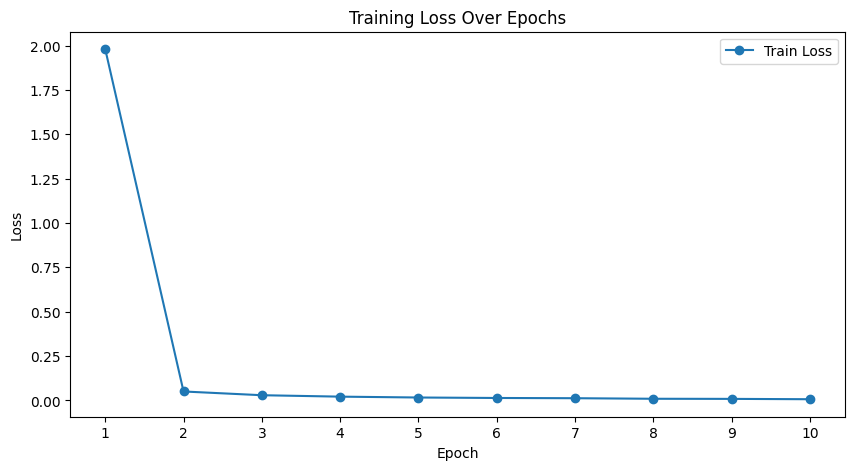

In [12]:
plt.figure(figsize=(10,5))
plt.plot( np.arange(1, len(training_losses) + 1), training_losses,label="Train Loss", marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(np.arange(1, len(training_losses) + 1))
plt.legend()
plt.show()